In [6]:
import json
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
full_data = pd.DataFrame()

# Go through all files in the data folder
for file in os.listdir("logs"):
    if file.endswith(".csv"):

        loader, caption, nb_loading, nb_chunking = file.split("_")
        nb_chunking = nb_chunking.split(".")[0]

        data = pd.read_csv(f"logs/{file}")
        data["loader"] = loader
        data["caption"] = caption
        data["nb_loading"] = nb_loading
        data["nb_chunking"] = nb_chunking

        # Charger les temps de chunking depuis le JSON
        json_path = f"logs/{file.replace('.csv', '.json')}"
        with open(json_path) as f:
            json_data = json.load(f)

        # Extraire les valeurs des temps de chunking
        if isinstance(json_data, dict) and "chunking_times" in json_data:
            chunking_times = list(json_data["chunking_times"].values())  # Récupération des valeurs

            if len(chunking_times) == len(data):
                data["chunking_time"] = chunking_times
            else:
                print(f"Avertissement : Wrong number of times for {file}")
                print(f"Expected {len(data)} times, got {len(chunking_times)}")
                print(chunking_times)
                data["chunking_time"] = None
        else:
            print(f"Avertissement : 'chunking_times' not found in JSON for {file}")
            data["chunking_time"] = None

        full_data = pd.concat([full_data, data], ignore_index=True)

# Nettoyage des noms de fichiers
full_data["file"] = full_data["file"].apply(lambda x: x.split("/")[-1])

full_data


,file,tot_time,time_convert,time_caption,loader,caption,nb_loading,nb_chunking,chunking_time
0,Kynurenine pathway ALS.pdf,64.537126,57.506790,7.029739,MarkerLoader,True,1,3,35.907892
1,Manifeste-CannabiSante-PrincipesActifs.pdf,34.821800,20.036647,14.784467,MarkerLoader,True,1,3,4.404689
2,Fiche de positionnement Hospitalidée octobre ...,5.188518,1.411491,3.776759,MarkerLoader,True,1,3,11.356263
3,i974 rapport rabouté - l17b0974_rapport-infor...,177.160873,121.367999,55.787693,MarkerLoader,True,1,3,127.253019
4,Note de positionnement Pensons Patients.pdf,92.503855,92.502673,0.000944,MarkerLoader,True,1,3,219.886393
...,...,...,...,...,...,...,...,...,...
271,BUTYRATE ET GUT INFLAMMATION.pdf,198.526942,95.412441,103.113601,DoclingLoader,True,2,2,41.934179
272,Note Syndrome de Prader-Willi V2 Jan 22.pdf,7.824770,1.762017,6.062277,DoclingLoader,True,2,2,36.805371
273,Leaky gut in systemic infammation.pdf,11.178893,11.030465,0.147849,DoclingLoader,True,2,2,29.312977
274,202407_charte-de-deontologie-AFCL.pdf,7.973790,2.089933,5.883394,DoclingLoader,True,2,2,41.783079


In [8]:
sns.set_theme(style="whitegrid")

# Compare Docling and Marker

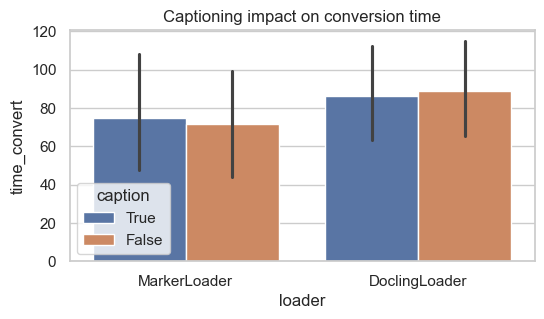

In [9]:
plt.figure(figsize=(6, 3))
plt.title("Captioning impact on conversion time")

sns.barplot(
    x="loader",
    y="time_convert",
    hue="caption",
    data=full_data[full_data["caption"].isin(["True", "False"])],
    dodge=True  # Permet d'afficher les barres côte à côte
)

plt.show()


# Indiscriminate difference between Docling and Marker

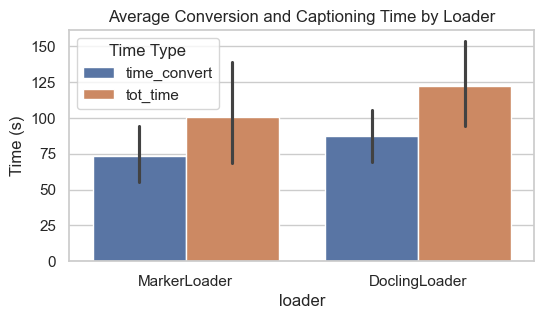

In [10]:
plt.figure(figsize=(6, 3))
plt.title("Average Conversion and Captioning Time by Loader")

# Reshape the data for Seaborn
melted_data = full_data.melt(
    id_vars=["loader"], 
    value_vars=["time_convert", "tot_time"], 
    var_name="Time Type", 
    value_name="Time (s)"
)

sns.barplot(
    x="loader",
    y="Time (s)",
    hue="Time Type",
    data=melted_data,
    dodge=True  # Places bars side by side
)

plt.show()


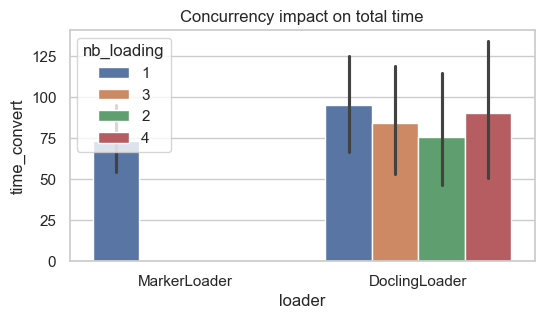

In [11]:
plt.figure(figsize=(6, 3))
plt.title("Concurrency impact on total time")

sns.barplot(
    x="loader",
    y="time_convert",
    hue="nb_loading",
    data=full_data[full_data["nb_loading"].isin(['1', '2', '3', '4'])],
    dodge=True  # Permet d'afficher les barres côte à côte
)

plt.show()